# 03 - Geometry & Panel-Placement Analysis

Demonstrates roof-area/usable-area/orientation/pitch estimation and real geometric panel placement on synthetic samples with known generation parameters, and contrasts the naive `area / panel_area` panel-count baseline against real rectangle packing.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import numpy as np

from src.data.synthetic import SyntheticRoofGenerator
from src.pipeline import SolarConfig, run_pipeline
from src.optimization.panel_placement import panel_count_naive_area_ratio
from src.visualization.plotting import plot_usable_area, plot_panel_placement

generator = SyntheticRoofGenerator(image_size=256, segment_scheme=9, gsd_m_per_px=0.10, seed=7)

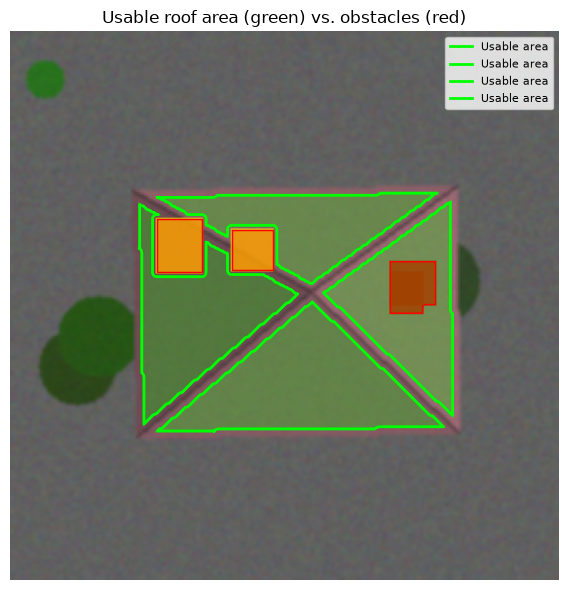

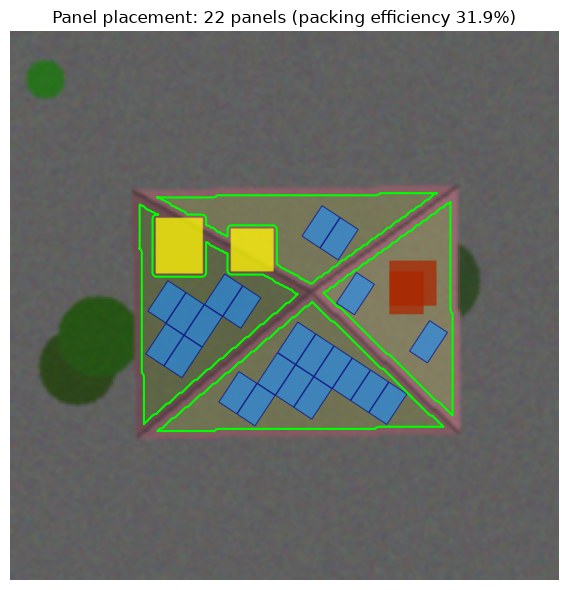

,sample,archetype,roof_area_m2,usable_area_m2,real_panel_count,naive_panel_count,capacity_kwp,pitch_estimate_deg,true_slope_deg (generation ground truth)
0,sample_0,hip,170.1,117.1,22,68,9.90,32.0,"[23.91544559350898, 23.91544559350898, 23.9154..."
1,sample_1,hip,256.2,199.9,55,117,24.75,32.0,"[23.318734740877673, 23.318734740877673, 23.31..."
2,sample_2,gable,123.6,99.7,31,58,13.95,35.0,"[28.652678729952676, 28.652678729952676]"
3,sample_3,gable,127.1,96.6,25,56,11.25,35.0,"[42.36302130853072, 42.36302130853072]"
4,sample_4,flat,224.7,167.8,65,98,29.25,2.0,[2.117296178197833]


In [2]:
rows = []
for i in range(5):
    sample = generator.generate(f'sample_{i}')
    solar_cfg = SolarConfig()
    result = run_pipeline(sample.image, solar_config=solar_cfg, gsd_m_per_px=sample.metadata['gsd_m_per_px'],
                          segment_mask=sample.segment_mask, superstructure_mask=sample.superstructure_mask)
    naive_count = panel_count_naive_area_ratio(result.usable.usable_polygon,
                                                solar_cfg.panel_width_m / result.gsd_m_per_px,
                                                solar_cfg.panel_height_m / result.gsd_m_per_px)
    rows.append({
        'sample': sample.sample_id, 'archetype': sample.metadata['archetype'],
        'roof_area_m2': round(result.usable.roof_area.area_m2, 1),
        'usable_area_m2': round(result.usable.usable_area.area_m2, 1),
        'real_panel_count': len(result.placement.panels),
        'naive_panel_count': int(naive_count),
        'capacity_kwp': round(result.capacity.capacity_kwp, 2),
        'pitch_estimate_deg': result.pitch.pitch_deg_typical,
        'true_slope_deg (generation ground truth)': [s['slope_deg'] for s in sample.metadata['segments']],
    })
    if i == 0:
        fig = plot_usable_area(sample.image, None, result.usable.usable_polygon,
                                sum(result.obstacle_polygons_by_class.values(), []))
        plt.show()
        fig = plot_panel_placement(sample.image, result.usable.usable_polygon, result.placement)
        plt.show()

import pandas as pd
df = pd.DataFrame(rows)
df

## Naive area/panel_area vs. real geometric placement

The naive ratio consistently overstates panel count relative to real rectangle packing, since it ignores boundary irregularity, obstacle clearance shape, and non-multiple roof dimensions -- exactly the argument in `docs/research_report.md` for why panel count must come from actual placement geometry.

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(df))
ax.bar(x - 0.2, df['naive_panel_count'], width=0.4, label='Naive area/panel_area')
ax.bar(x + 0.2, df['real_panel_count'], width=0.4, label='Real geometric placement')
ax.set_xticks(x)
ax.set_xticklabels(df['sample'], rotation=30)
ax.set_ylabel('Panel count')
ax.set_title('Naive area ratio vs. real placement (synthetic samples)')
ax.legend()
fig.tight_layout()
from src.visualization.plotting import save_figure
save_figure(fig, '../results/figures/naive_vs_real_panel_count.png')
plt.show()

## Sensitivity / uncertainty demonstration

In [4]:
sample = generator.generate('uncertainty_demo')
result = run_pipeline(sample.image, gsd_m_per_px=sample.metadata['gsd_m_per_px'],
                      segment_mask=sample.segment_mask, superstructure_mask=sample.superstructure_mask)
print('\n'.join(result.report_lines()))
print()
print(result.uncertainty.explanation)

Roof area: 118.6 m^2 [estimated (from provided GSD)]
Usable area: 95.6 m^2 [estimated (from provided GSD)]
Obstacle area removed: 0.0 m^2
Orientation: Southwest
Estimated pitch: ~35 deg (archetype heuristic, range 25-45 deg -- NOT a measurement)
Panels placed: 26 (packing efficiency 46%)
Panel rating: 450 W
Capacity: 11.7 kWp (theoretical installed capacity, not an energy-yield simulation)
Uncertainty range: 19-33 panels (High)

Range computed by re-running panel placement under +/-30% perturbations of the safety margin and obstacle clearance and +/-5% of GSD (a 3^3=27 full-factorial sensitivity sweep), This is an uncertainty ESTIMATE derived from the pipeline's own sensitivity, not a formally calibrated statistical confidence interval.
